# Amazon Product Analysis

## 1. Objective
Understand how discounts impact ratings and sales proxies.

## 2. Data Cleaning
- Handle nulls
- Convert types

## 3. Feature Engineering
- Price segments
- Weighted ratings

## 4. Analysis
- Price vs rating
- Discount vs rating
- Category-level insights

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/Dhruv/Downloads/projects/amazon_sales/amazon_sales.csv")
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [2]:
print(df.shape)

(1465, 16)


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [7]:
print(df.describe())

        product_id                                       product_name  \
count         1465                                               1465   
unique        1351                                               1337   
top     B07JW9H4J1  Fire-Boltt Ninja Call Pro Plus 1.83" Smart Wat...   
freq             3                                                  5   

                                                 category discounted_price  \
count                                                1465             1465   
unique                                                211              550   
top     Computers&Accessories|Accessories&Peripherals|...             ₹199   
freq                                                  233               53   

       actual_price discount_percentage rating rating_count  \
count          1465                1465   1465         1463   
unique          449                  92     28         1143   
top            ₹999                 50%    4.1        

In [4]:
df['product_id'].nunique()

1351

In [5]:
df = df.drop_duplicates('product_id')
print(df.shape)

(1351, 16)


In [6]:
df['discounted_price'] = (
    df['discounted_price']
    .str.replace('₹','',regex=False)
    .str.replace(',','',regex=False)
)

In [11]:
numeric_discounted_price = pd.to_numeric(df['discounted_price'], errors='coerce')
non_numeric_mask=numeric_discounted_price.isna()
non_numeric_discounted_price=df[non_numeric_mask]['discounted_price']
print(non_numeric_discounted_price)

Series([], Name: discounted_price, dtype: object)


In [7]:
df['discounted_price']=pd.to_numeric(df['discounted_price'], errors='coerce')

In [8]:
df['actual_price'] = (
    df['actual_price']
    .str.replace('₹','',regex=False)
    .str.replace(',','',regex=False)
)

In [9]:
numeric_actual_price = pd.to_numeric(df['actual_price'], errors='coerce')
non_numeric_mask=numeric_actual_price.isna()
non_numeric_actual_price=df[non_numeric_mask]['actual_price']
print(non_numeric_actual_price)

Series([], Name: actual_price, dtype: object)


In [10]:
df['actual_price']=pd.to_numeric(df['actual_price'], errors='coerce')

In [11]:
df['discount_percentage'] = (
    df['discount_percentage']
    .str.replace('%','',regex=False)
    .str.replace(',','',regex=False)
)

In [12]:
numeric_discounted_per = pd.to_numeric(df['discount_percentage'], errors='coerce')
non_numeric_mask=numeric_discounted_per.isna()
non_numeric_discounted_per=df[non_numeric_mask]['discount_percentage']
print(non_numeric_discounted_per)

Series([], Name: discount_percentage, dtype: object)


In [13]:
df['discount_percentage']=pd.to_numeric(df['discount_percentage'], errors='coerce')

In [14]:
numeric_rating = pd.to_numeric(df['rating'], errors='coerce')
non_numeric_mask=numeric_rating.isna()
non_numeric_rating=df[non_numeric_mask]['rating']
print(non_numeric_rating)

1279    |
Name: rating, dtype: object


In [15]:
df[non_numeric_mask]

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
1279,B08L12N5H1,Eureka Forbes car Vac 100 Watts Powerful Sucti...,"Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cle...",2099.0,2499.0,16,|,992,No Installation is provided for this product|1...,"AGTDSNT2FKVYEPDPXAA673AIS44A,AER2XFSWNN4LAUCJ5...","Divya,Dr Nefario,Deekshith,Preeti,Prasanth R,P...","R2KKTKM4M9RDVJ,R1O692MZOBTE79,R2WRSEWL56SOS4,R...","Decent product,doesn't pick up sand,Ok ok,Must...","Does the job well,doesn't work on sand. though...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Eureka-Forbes-Vacuum-Cle...


In [16]:
df['rating']=pd.to_numeric(df['rating'], errors='coerce')
df=df.dropna(subset=['rating'])
print(df.shape)

(1350, 16)


In [17]:
df['rating_count'] = (
    df['rating_count']
    .str.replace('%','',regex=False)
    .str.replace(',','',regex=False)
)

In [18]:
numeric_rating_count = pd.to_numeric(df['rating_count'], errors='coerce')
non_numeric_mask=numeric_rating_count.isna()
non_numeric_rating_count=df[non_numeric_mask]['rating_count']
print(non_numeric_rating_count)

282    NaN
324    NaN
Name: rating_count, dtype: object


In [19]:
df['rating_count']=pd.to_numeric(df['rating_count'], errors='coerce')
df=df.dropna(subset=['rating_count'])

In [21]:
df['savings']=df['actual_price']-df['discounted_price']
df.sort_values('savings',ascending=False).head(10)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link,savings
249,B09WN3SRC7,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...,"Electronics|HomeTheater,TV&Video|Televisions|S...",77990.0,139900.0,44,4.7,5935.0,Resolution: 4K Ultra HD (3840 x 2160) | Refres...,"AF6Z2OYIXRPZJHVYN2MFKKYHPHFQ,AH5SAORYVUN5MGIBL...","David P.,Dr. ATUL THAKUR,Shriniwas Patil,Tahir...","R16HCZ0W1TRSMM,R12J7UKQ0FX3O9,R8729SR7LQFUU,R1...",Product installation was excellent but delive...,The delivery people were not careful with the ...,https://m.media-amazon.com/images/I/51uVckL1jR...,https://www.amazon.in/Sony-Bravia-inches-Googl...,61910.0
1182,B08GJ57MKL,"Coway Professional Air Purifier for Home, Long...","Home&Kitchen|Heating,Cooling&AirQuality|AirPur...",14400.0,59900.0,76,4.4,3837.0,Coway,"AHHUP4DBXB2AQMEO27XIQ3DJSVDQ,AEIUS76RRWIKCMNHH...","Dhatwalia,Tahir Abdulla,Surya Pratap Singh,VIJ...","R33RASBIQKH1EX,RBOPA6420OHEP,R200UL35KLRW7R,RJ...","No visible change,Effective,Sensitivity, Simpl...",Lights inbuilt in this create psychological ef...,https://m.media-amazon.com/images/I/51b5sh94f7...,https://www.amazon.in/Coway-Professional-Purif...,45500.0
568,B08VB57558,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",Electronics|Mobiles&Accessories|Smartphones&Ba...,37990.0,74999.0,49,4.2,27790.0,5G Ready powered by Qualcomm Snapdragon 865 Oc...,"AEGEOVAES62OFGQTSPSDSQ5U7SHA,AGMBYTP5MS3JCQZ2N...","Mohammed Suhail,GVR","R3R5DS04EXELTJ,R3JBXYOBYRX0A8","WORTH BUY ! THE BEST,Good for the price.",It's been 15 days since i using the device ext...,https://m.media-amazon.com/images/I/41ezRvTwca...,https://www.amazon.in/Samsung-Galaxy-Cloud-128...,37009.0
150,B0BB3CBFBM,VU 138 cm (55 inches) Premium Series 4K Ultra ...,"Electronics|HomeTheater,TV&Video|Televisions|S...",29990.0,65000.0,54,4.1,211.0,Resolution: 4K (3840x2160) | Refresh Rate: 60 ...,"AEH3MURR76DG3TEX3NXIJVJTKBLA,AGGEFVVI6ZRLVEJHV...","CH Venkatesh,nihar mendon,IP Trading solutions...","RG3VFGY4HM38X,R957RND66RVWX,R1YR2TZI534FFY,R3V...","Valume for money,Can’t turn off HDR in webOS w...","Vu UHD SMART 43"" web os version good tv 20...",https://m.media-amazon.com/images/I/41HhmJpfjN...,https://www.amazon.in/VU-inches-Premium-Ultra-...,35010.0
1354,B09NS5TKPN,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,"Home&Kitchen|Heating,Cooling&AirQuality|AirCon...",42990.0,75990.0,43,4.3,3231.0,Split AC with inverter compressor: variable sp...,"AGBYWFEGGX6QM6XB3ZPQADKKXAHA,AGU6LHFOEHAFE34AC...","ABHISHEK KUMAR,Nageswar,Denzil,krushna,Brijesh...","R2GZHWNGVMBJFG,R3L27H7N1WH5BG,R200QONLM29B4B,R...","Very nice,Efficient but little costly.,Good pr...","Very nice,Efficiency is good , cost is little ...",https://m.media-amazon.com/images/I/21ywp-zfTj...,https://www.amazon.in/LG-Convertible-Anti-Viru...,33000.0
283,B0B3XXSB1K,LG 139 cm (55 inches) 4K Ultra HD Smart LED TV...,"Electronics|HomeTheater,TV&Video|Televisions|S...",47990.0,79990.0,40,4.3,1376.0,Resolution: 4K Ultra HD (3840x2160) | Refresh ...,"AFCWL3MX7BP2ZUDD37MEAENZDQ2A,AGGFXDLCFZMTLJJDR...","Raj Mohammed,Samson,Haroon sayeed,P Imran Khan...","RC3ZLDRM8GA9T,RMDN4PSDM8SKK,R1YFAMDJ7P0SY3,R2W...","Love Amazon but lg is misleading,Amazing produ...",There's no magic remote and lg should include ...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/LG-inches-Ultra-55UQ7500...,32000.0
1306,B0B19VJXQZ,ECOVACS DEEBOT N8 2-in-1 Robotic Vacuum Cleane...,"Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cle...",27900.0,59900.0,53,4.4,5298.0,FREE HOME INSTALLATION & FREE HOME SERVICE: We...,"AFDTW4TES6JHT7YJUXKDFQJPRZXQ,AFEBFFAOMPMC6L3DM...","Jaydeep,Jayakrishnan R","R1BD0HURZRIGKV,RKQY8Y6U3Y4BT","A perfect balance of price and performance,Gre...",Very happy with the product performance.Instal...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/ECOVACS-Robotic-Powerful...,32000.0
25

### Top 10 rated category based on rating & rating_count?

In [22]:
weighted_category = (
    df.groupby('category').apply(lambda x: (x['rating'] *
                                x['rating_count']).sum() /
                                x['rating_count'].sum())
                          .sort_values(ascending=False).head(10)
)
print('Top 10 rated category based on rating & rating_count: \n',weighted_category.reset_index())

Top 10 rated category based on rating & rating_count: 
                                             category         0
0                      Computers&Accessories|Tablets  4.600000
1  Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...  4.553436
2  Electronics|Mobiles&Accessories|MobileAccessor...  4.535626
3  Home&Kitchen|Kitchen&HomeAppliances|Coffee,Tea...  4.500000
4  Computers&Accessories|NetworkingDevices|Networ...  4.500000
5          HomeImprovement|Electrical|CordManagement  4.500000
6  OfficeProducts|OfficeElectronics|Calculators|B...  4.500000
7  Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...  4.500000
8   Electronics|Cameras&Photography|Accessories|Film  4.500000
9       Electronics|PowerAccessories|SurgeProtectors  4.500000


### Top 10 discounted category based on discount_percentage?

In [23]:
top_10_category_disc = df.groupby('category')['discount_percentage'].mean().sort_values(ascending=False).head(10)
print("Top 10 discounted category based on discount_percentage:\n",top_10_category_disc.reset_index())

Top 10 discounted category based on discount_percentage:
                                             category  discount_percentage
0  Electronics|Mobiles&Accessories|MobileAccessor...                 90.0
1  Computers&Accessories|Accessories&Peripherals|...                 90.0
2  Electronics|Headphones,Earbuds&Accessories|Ear...                 90.0
3  Electronics|Headphones,Earbuds&Accessories|Ada...                 88.0
4  Computers&Accessories|Accessories&Peripherals|...                 87.5
5  Electronics|Mobiles&Accessories|MobileAccessor...                 82.0
6  Computers&Accessories|Components|InternalHardD...                 80.0
7  Computers&Accessories|Accessories&Peripherals|...                 78.5
8  Electronics|Mobiles&Accessories|MobileAccessor...                 76.4
9   Electronics|Headphones,Earbuds&Accessories|Cases                 76.0


### What is the impact of discounted_price on rating?

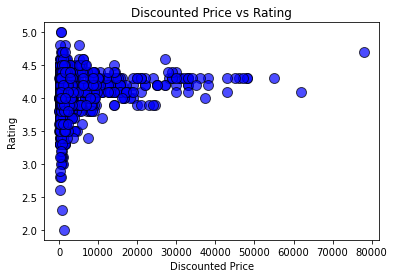

In [25]:
df_clean = df[['discounted_price','rating']].dropna() 

plt.scatter(df_clean['discounted_price'], df_clean['rating'], color='blue', marker='o', s=100, alpha=0.7, edgecolors='black')
plt.title("Discounted Price vs Rating")
plt.xlabel("Discounted Price")
plt.ylabel("Rating")
plt.show()

### Top 10 most reviewed products?

In [26]:
df.sort_values('rating_count',ascending=False).head(10)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link,savings
65,B014I8SX4Y,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...","Electronics|HomeTheater,TV&Video|Accessories|C...",309.0,1400.0,78,4.4,426973.0,HDMI A Male to A Male Cable: Supports Ethernet...,"AEYJ5I6JZZPOJB6MGWRQOHRQLPSQ,AFY5TVFOMVHGBPBTI...","Rishav Gossain,Shashank Mallamraju,Purnendu,gu...","R1FKOKZ3HHKJBZ,R2WNMZI1EXTA0H,RCA1M3W4RIXUR,R3...","It's quite good and value for money,Works well...",I am using it for 14 days now. The experience ...,https://m.media-amazon.com/images/I/41eJqkFjCR...,https://www.amazon.in/AmazonBasics-High-Speed-...,1091.0
47,B014I8SSD0,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...","Electronics|HomeTheater,TV&Video|Accessories|C...",309.0,475.0,35,4.4,426973.0,Please select appropriate display resolution &...,"AEYJ5I6JZZPOJB6MGWRQOHRQLPSQ,AFY5TVFOMVHGBPBTI...","Rishav Gossain,Shashank Mallamraju,Purnendu,gu...","R1FKOKZ3HHKJBZ,R2WNMZI1EXTA0H,RCA1M3W4RIXUR,R3...","It's quite good and value for money,Works well...",I am using it for 14 days now. The experience ...,https://m.media-amazon.com/images/I/41bCxnHksn...,https://www.amazon.in/AmazonBasics-High-Speed-...,166.0
12,B07KSMBL2H,AmazonBasics Flexible Premium HDMI Cable (Blac...,"Electronics|HomeTheater,TV&Video|Accessories|C...",219.0,700.0,69,4.4,426973.0,"Flexible, lightweight HDMI cable for connectin...","AEYJ5I6JZZPOJB6MGWRQOHRQLPSQ,AFY5TVFOMVHGBPBTI...","Rishav Gossain,Shashank Mallamraju,Purnendu,gu...","R1FKOKZ3HHKJBZ,R2WNMZI1EXTA0H,RCA1M3W4RIXUR,R3...","It's quite good and value for money,Works well...",I am using it for 14 days now. The experience ...,https://m.media-amazon.com/images/I/41nPYaWA+M...,https://www.amazon.in/AmazonBasics-Flexible-HD...,481.0
400,B07GQD4K6L,boAt Bassheads 100 in Ear Wired Earphones with...,"Electronics|Headphones,Earbuds&Accessories|Hea...",379.0,999.0,62,4.1,363713.0,The perfect way to add some style and stand ou...,"AF4MVO4JNFDEPWFKZO62OAJKRIWA,AHVPAXEWPATRASBKH...","tarun kumar,mahesh radheshyam tawari,Blackspad...","R2DD2M5YARW7R2,R2M9ZYNGGV1ZLN,RNWNTRNLSJWSB,R3...","Best value for money,HEAD PHONE POUCH NOT RECE...",The sound quality of this earphone are really ...,https://m.media-amazon.com/images/I/31qVddHyy5...,https://www.amazon.in/Boat-BassHeads-100-Inspi...,620.0
352,B07GPXXNNG,boAt Bassheads 100 in Ear Wired Earphones with...,"Electronics|Headphones,Earbuds&Accessories|Hea...",349.0,999.0,65,4.1,363713.0,The perfect way to add some style and stand ou...,"AF4MVO4JNFDEPWFKZO62OAJKRIWA,AHVPAXEWPATRASBKH...","tarun kumar,mahesh radheshyam tawari,Blackspad...","R2DD2M5YARW7R2,R2M9ZYNGGV1ZLN,RNWNTRNLSJWSB,R3...","Best value for money,HEAD PHONE POUCH NOT RECE...",The sound quality of this earphone are really ...,https://m.media-amazon.com/images/I/31J6I7SrLX...,https://www.amazon.in/Boat-BassHeads-100-Inspi...,650.0
584,B071Z8M4KX,boAt BassHeads 100 in-Ear Wired Headphones wit...,"Electronics|Headphones,Earbuds&Accessories|Hea...",365.0,999.0,63,4.1,363711.0,The perfect way to add some style and stand ou...,"AF4MVO4JNFDEPWFKZO62OAJKRIWA,AHVPAXEWPATRASBKH...","tarun kumar,mahesh radheshyam tawari,Blackspad...","R2DD2M5YARW7R2,R2M9ZYNGGV1ZLN,RNWNTRNLSJWSB,R3...","Best value for money,HEAD PHONE POUCH NOT RECE...",The sound quality of this earphone are really ...,https://m.media-amazon.com/images/I/31IdiM9ZM8...,https://www.amazon.in/boAt-BassHeads-100-Headp...,634.0
371,B09GFLXVH9,"Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...",Electronics|Mobiles&Accessories|Smartphones&Ba...,6499.0,8499.0,24,4.1,313836.0,Processor: MediaTek Helio G25 Octa-core; Up to...,"AF7B5AJJZP2WKRD74Z45L7YDOEHA,AGEYI2JEUE752XDEX...","Roshan Renji Cherian,SivavaraprasadPV,Kranthi,...","RCP907FSHW2CI,R2XSNFIDSF8IL4,R2JB9PO5MV9LER,R1...","Best phone for below normal use,Good mobile fo...",If you want a smart phone for ju

### What are the top 10 most rated category?

In [27]:
print("Top 10 Most Rated Categories: ")
df.groupby('category')['rating_count'].mean().sort_values(ascending=False).head(10).reset_index()

Top 10 Most Rated Categories: 


,category,rating_count
0,Home&Kitchen|Kitchen&Dining|KitchenTools|Manua...,270563.000000
1,Computers&Accessories|NetworkingDevices|Networ...,95116.000000
2,Electronics|Accessories|MemoryCards|MicroSD,87367.000000
3,"Electronics|Headphones,Earbuds&Accessories|Hea...",78673.568627
4,Computers&Accessories|ExternalDevices&DataStor...,77474.400000
5,Computers&Accessories|NetworkingDevices|Repeat...,74123.666667
6,Electronics|Accessories|MemoryCards|SecureDigi...,69585.000000
7,"Electronics|HomeTheater,TV&Video|Accessories|C...",69331.761905
8,"Electronics|Headphones,Earbuds&Accessories|Hea...",63670.857143
9,Electronics|Mobiles&Accessories|Smartphones&Ba...,61139.888889


### Do the most discounted categories also have highest rating?

In [46]:
category_stats = df.groupby('category').agg(
    avg_discount=('discount_percentage', 'mean'),
    weighted_rating=('rating', lambda x: np.average(x, weights=df.loc[x.index, 'rating_count']))
).reset_index()

In [47]:
category_stats.columns

Index(['category', 'avg_discount', 'weighted_rating'], dtype='object')

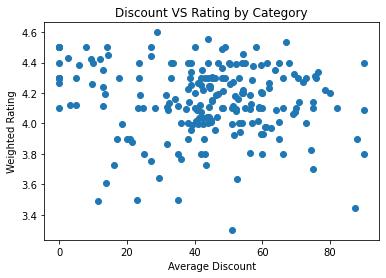

In [48]:
top_discount = category_stats.sort_values(by = 'avg_discount', ascending = False)

plt.scatter(category_stats['avg_discount'], category_stats['weighted_rating'])
plt.xlabel('Average Discount')
plt.ylabel('Weighted Rating')
plt.title('Discount VS Rating by Category')
plt.show()

In [49]:
category_stats[['avg_discount', 'weighted_rating']].corr()

,avg_discount,weighted_rating
avg_discount,1.000000,-0.143249
weighted_rating,-0.143249,1.000000


### Price segementation

In [50]:
def price_bucket(p):
    if p < 200:
        return 'Budget'
    elif p < 1000:
        return 'Mid'
    else:
        return 'Premium'

df['price_segment'] = df['discounted_price'].apply(price_bucket)

In [51]:
df.groupby('price_segment')['rating'].mean()

price_segment
Budget     4.039873
Mid        4.092042
Premium    4.105392
Name: rating, dtype: float64

### Discount VS Review Volume

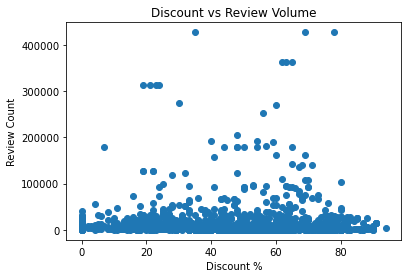

In [52]:
plt.scatter(df['discount_percentage'], df['rating_count'])
plt.xlabel('Discount %')
plt.ylabel('Review Count')
plt.title('Discount vs Review Volume')
plt.show()

In [55]:
print('Correlation:')
df[['discount_percentage', 'rating_count']].corr()

Correlation:


,discount_percentage,rating_count
discount_percentage,1.000000,0.003443
rating_count,0.003443,1.000000


## Key Insights

- No strong correlation between discount and rating → discounts don't improve satisfaction
- High discounts correlate with higher review volume → likely increased sales
- Budget products tend to have slightly higher ratings → expectation effect

## Recommendation

- Discounting drives volume, not satisfaction. Focus on product quality, not just pricing strategy.